# Comparing the Summer Drought in Serbia using openEO

During the summer of 2026, a large area of Central and Eastern Europe experienced prolonged heat and reduced precipitation. A severe summer drought and prolonged heatwaves pushed the Danube River to a historic low in Serbia, dropping past minus 120 centimeters ([source](https://www.vreme.com/en/drustvo/dunav-istorijski-minimum-vodostaj-susa-klimatske-promene/)). Vegetation under drought stress typically exhibits:

- lower moisture content
- reduced greenness
- reduced crop vigor

This notebook demonstrates how drought conditions can be quickly assessed using openEO, without downloading raw Sentinel-2 scenes locally. It covers:

* accessing Sentinel-2 imagery from CDSE for 2016 and 2026
* cloud masking using openEO's built-in process
* calculating NDDI (Normalized Difference Drought Index) directly with the Awesome Spectral Indices package

NDDI combines:
* NDVI (vegetation greenness/vigor)
* NDWI (vegetation water content)

Import the `compute_indices` helper from `openeo.extra.spectral_indices`, which we'll use to compute NDDI later in the workflow.

In [1]:
import openeo
from openeo import MultiResult
from openeo.extra.spectral_indices import compute_indices

Authenticate with the openEO Federation endpoint (`openeofed.dataspace.copernicus.eu`).


In [2]:
connection = openeo.connect("openeofed.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


Define the study area (a bounding box around the Danube in Serbia) and the Sentinel-2 bands needed for NDDI: `B03` (green), `B04` (red), `B08` (NIR), and `B11` (SWIR) — used internally by the Awesome Spectral Indices package to derive NDVI and NDWI.

In [3]:
bbox = {
  "west": 22.45,
  "south": 44.15,
  "east": 22.85,
  "north": 44.45,
  "crs": "EPSG:4326"
}
bands = ["B03","B04","B08","B11"]

Use Awesome Spectral Indices directly inside an openEO workflow.

NDDI is defined as:

$$NDDI = \frac{NDVI - NDWI}{NDVI + NDWI}$$

Since we will be computing the NDDI cube for two different temporal extents, let's create a reusable function that loads Sentinel-2 data, applies SCL cloud masking, computes NDDI, and aggregates over time.

In [4]:
def build_nddi_cube(start_date, end_date):
    datacube = connection.load_collection(
        "SENTINEL2_L2A", 
        spatial_extent=bbox, 
        temporal_extent=[start_date,end_date], 
        bands=bands
        )
    scl = connection.load_collection(
        "SENTINEL2_L2A", 
        spatial_extent=bbox, 
        temporal_extent=[start_date,end_date], 
        bands=["SCL"]
        )
    mask = scl.process("to_scl_dilation_mask", data=scl)
    masked_cube = datacube.mask(mask)
    nddi = compute_indices(datacube=masked_cube, indices=["NDDI"])
    return nddi.reduce_dimension(dimension="t", reducer="mean")

Run the same NDDI pipeline over two time windows to highlight drought-affected areas: **May-July 2016** as the baseline year, and **May-July 2026** as the drought year.

In [5]:
nddi_2016 = build_nddi_cube("2016-05-01","2016-07-31")
nddi_2026 = build_nddi_cube("2026-05-01","2026-07-31")

Use openEO's `MultiResult` process, which allows saving outputs from two different cubes in a single batch job.

In [6]:
# first result
nddi_2025_result = nddi_2016.save_result(format="GTiff", options={"filename_prefix": "NDDI_2016"})

# comparison as second result
nddi_2026_result = nddi_2026.save_result(format="GTiff", options={"filename_prefix": "NDDI_2026"})

multi_result_nddi = MultiResult([nddi_2025_result,nddi_2026_result])
nddi_job = multi_result_nddi.create_job(title="NDDI 2016 vs 2026")
nddi_job.start_and_wait()

0:00:00 Job 'cdse-j-2608060803094f12ae7623f57e33d883': send 'start'
0:00:04 Job 'cdse-j-2608060803094f12ae7623f57e33d883': created (progress 0%)
0:00:09 Job 'cdse-j-2608060803094f12ae7623f57e33d883': queued (progress 0%)
0:00:16 Job 'cdse-j-2608060803094f12ae7623f57e33d883': queued (progress 0%)
0:00:24 Job 'cdse-j-2608060803094f12ae7623f57e33d883': queued (progress 0%)
0:00:34 Job 'cdse-j-2608060803094f12ae7623f57e33d883': queued (progress 0%)
0:00:46 Job 'cdse-j-2608060803094f12ae7623f57e33d883': queued (progress 0%)
0:01:03 Job 'cdse-j-2608060803094f12ae7623f57e33d883': running (progress N/A)
0:01:22 Job 'cdse-j-2608060803094f12ae7623f57e33d883': running (progress N/A)
0:01:47 Job 'cdse-j-2608060803094f12ae7623f57e33d883': running (progress N/A)
0:02:17 Job 'cdse-j-2608060803094f12ae7623f57e33d883': running (progress N/A)
0:02:54 Job 'cdse-j-2608060803094f12ae7623f57e33d883': running (progress N/A)
0:03:41 Job 'cdse-j-2608060803094f12ae7623f57e33d883': running (progress N/A)
0:04:39

<BatchJob job_id='cdse-j-2608060803094f12ae7623f57e33d883'>

After completion, fetch the result assets and download them locally into the `nddi_2016_vs_2026/` folder. These files are used for the static map comparison and zoom analysis below.

In [7]:
results = nddi_job.get_results()
results.download_files("nddi_2016_vs_2026/")

[WindowsPath('nddi_2016_vs_2026/NDDI_2016.tif'),
 WindowsPath('nddi_2016_vs_2026/NDDI_2026.tif'),
 WindowsPath('nddi_2016_vs_2026/job-results.json')]

Import raster and plotting libraries for the side-by-side map visualization. `rasterio` reads the GeoTIFFs and `matplotlib` renders the fixed-scale drought maps.

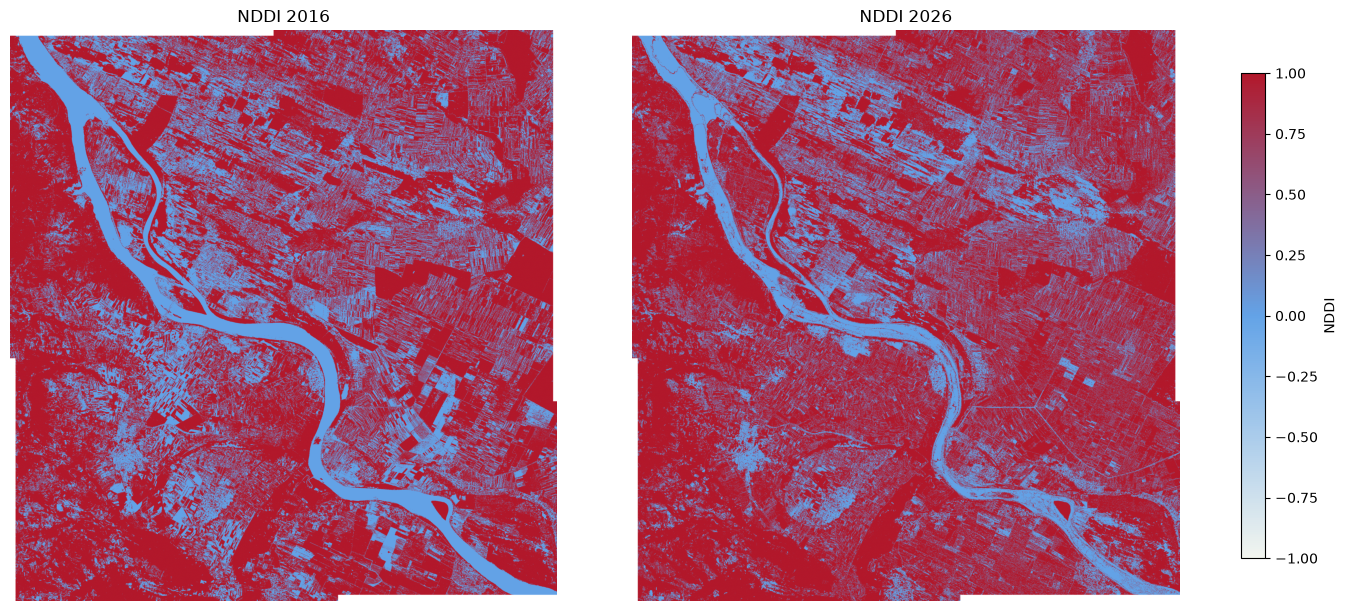

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
import rasterio
from rasterio.plot import show

# Read directly from result GeoTIFF files
with rasterio.open("nddi_2016_vs_2026/NDDI_2016.tif") as src16:
    arr16 = src16.read(1, masked=True)
with rasterio.open("nddi_2016_vs_2026/NDDI_2026.tif") as src26:
    arr26 = src26.read(1, masked=True)

# Clip to valid NDDI range
arr16 = np.ma.clip(arr16, -1, 1)
arr26 = np.ma.clip(arr26, -1, 1)

# Drought color palette: wet -> neutral -> dry
drought_cmap = LinearSegmentedColormap.from_list(
    "drought",
    ["#f2f5ef", "#63a3e7", "#b2182b"],
    N=256
)

# Fixed visual range for direct comparison
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

show(arr16, ax=axes[0], cmap=drought_cmap, norm=norm)
axes[0].set_title("NDDI 2016")
axes[0].set_axis_off()

show(arr26, ax=axes[1], cmap=drought_cmap, norm=norm)
axes[1].set_title("NDDI 2026")
axes[1].set_axis_off()

sm = plt.cm.ScalarMappable(norm=norm, cmap=drought_cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.85)
cbar.set_label("NDDI")

fig.savefig("nddi_2016_vs_2026_alt_plot.png", dpi=300, bbox_inches="tight")
plt.show()

Visually, the 2026 map shows a larger, more contiguous extent of deep-red pixels than 2016, particularly in the upper-right and lower-right agricultural blocks, suggesting more widespread vegetation/moisture stress in the 2026 growing season. 

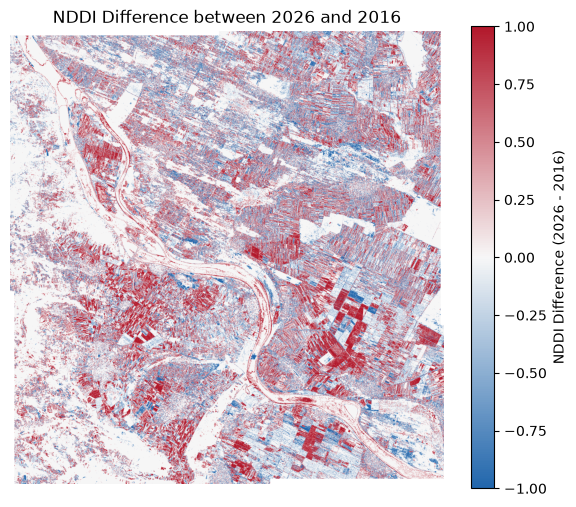

In [25]:
# plot the difference between 2026 and 2016
diff = arr26 - arr16
plt.figure(figsize=(7, 6))
# Difference color palette: negative -> neutral -> positive
diff_cmap = LinearSegmentedColormap.from_list(
    "diff",
    ["#2166ac", "#f7f7f7", "#b2182b"],
    N=256
)
plt.imshow(diff, cmap=diff_cmap, vmin=-1, vmax=1)
plt.colorbar(label="NDDI Difference (2026 - 2016)")
plt.title("NDDI Difference between 2026 and 2016")
plt.axis('off')
#save the difference plot
plt.savefig("nddi_difference_2026_2016.png", dpi=300, bbox_inches="tight")
plt.show()

Furthermore, the difference map (2026 − 2016) makes this more concrete: red pixels (positive difference) mark areas where NDDI rose over the decade, i.e., got drier/more stressed, While blue marks areas that got relatively wetter. Red clearly dominates over blue across most of the cropland, especially in the large agricultural parcel in the bottom-right of the scene, indicating a broad drying signal consistent with the 2026 drought.